In [1]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

In [2]:
#upload the pickle file
with open('/home/stefano/Documents/Spatial-Transcriptomic/results/rctd_result/weights/cell_type_abbundance.pkl', 'rb') as f:
    cell_type_abbundance = pickle.load(f)

In [4]:
cell_type_abbundance

{'blocco1_c26STAT3':                       n  proportions
 Endothelial          36         0.01
 FAPs                 51         0.01
 Immune_Cells         54         0.02
 MuSC                  2         0.00
 Myonuclei_IIb        33         0.01
 Myonuclei_IIx       316         0.09
 Myonuclei_IIx_IIa   707         0.20
 Myonuclei_IIx_IIb     2         0.00
 Myonuclei_MTJ        20         0.01
 Myonuclei_NMJ        11         0.00
 Myonuclei_Trim63   2321         0.65
 Nervous_System        5         0.00
 Pericyte              1         0.00
 Smooth_Muscular       0         0.00
 Tenocyte              2         0.00,
 'blocco1_c26foxO':                       n  proportions
 Endothelial          19         0.00
 FAPs                 34         0.01
 Immune_Cells          8         0.00
 MuSC                  2         0.00
 Myonuclei_IIb        17         0.00
 Myonuclei_IIx       100         0.02
 Myonuclei_IIx_IIa   596         0.14
 Myonuclei_IIx_IIb     0         0.00
 Myonuclei

In [18]:
myonuclei = ['Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIx_IIa', 'Myonuclei_IIx_IIb']

In [9]:
block_of_interest = ['blocco1_sham', 'blocco2_c26', 'blocco3_sham',
                  'blocco6_c26', 'blocco6_sham', 'blocco7_c26','blocco7_sham']
myonuclei_dict = {key: cell_type_abbundance[key] for key in block_of_interest}

In [28]:
abbundance = {}
for block in myonuclei_dict:
    abbundance[block] = myonuclei_dict[block].loc[myonuclei,:]

In [32]:
rows_list = []

for block_id, df_block in abbundance.items():
    
    # Determiniamo la condizione dal nome del blocco (Aggiusta la logica se serve)
    if "c26" in block_id.lower():
        condition = "C26"
    elif "sham" in block_id.lower():
        condition = "SHAM"
    else:
        condition = "Unknown"
        
    # Iteriamo sulle righe del DataFrame del singolo blocco
    for cell_type, row in df_block.iterrows():
        # Assicuriamoci di prendere la proporzione
        prop_value = row['proportions'] if 'proportions' in row else row['proportion']
        
        rows_list.append({
            'block_id': block_id,
            'condition': condition,
            'Myonuclear_Type': str(cell_type),
            'Proportion': float(prop_value)
        })

In [36]:
# create an unique dataframe in a long format
df_all = pd.DataFrame(rows_list)

# Se vuoi filtrare o ordinare solo i tipi di mionuclei di interesse:
myo_order = ['Myonuclei_IIa', 'Myonuclei_IIx', 'Myonuclei_IIb']
df_filtered = df_all[df_all['Myonuclear_Type'].isin(myonuclei)].copy()

/tmp/ipykernel_32216/3008422724.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
/tmp/ipykernel_32216/3008422724.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')


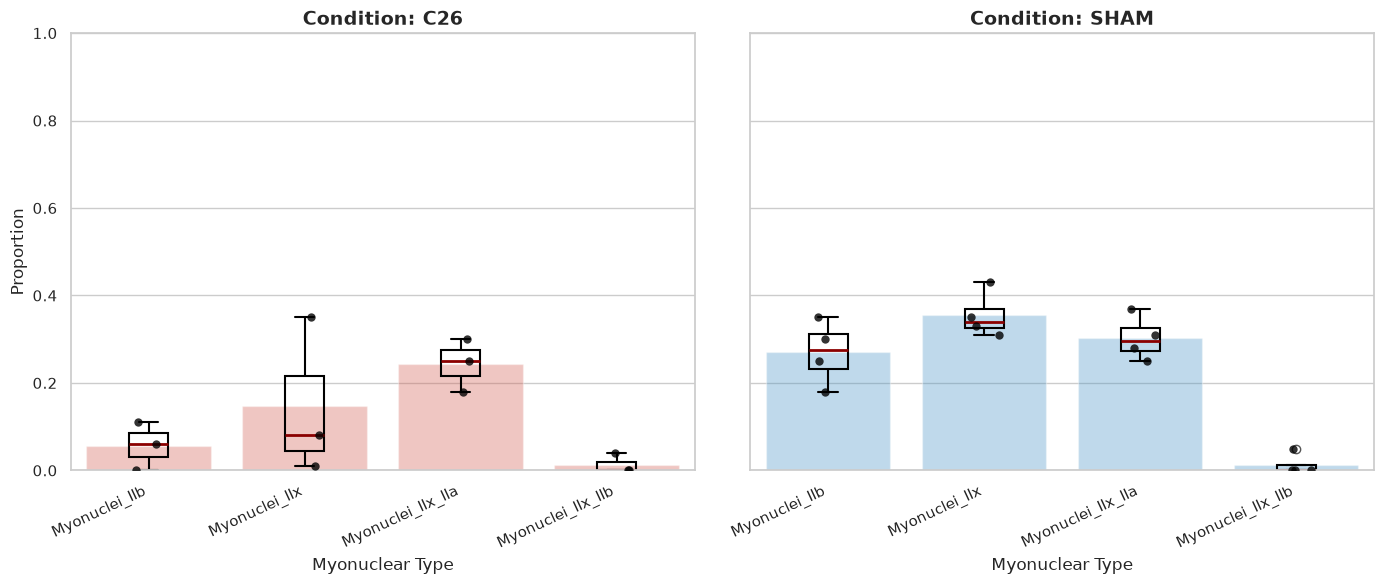

In [38]:
# Generazione del grafico (Barplot + Boxplot + Striplot)
sns.set_theme(style="whitegrid", palette="muted")

# Creiamo una figura con 2 subplot affiancati: uno per C26 e uno per SHAM
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

conditions = ['C26', 'SHAM']
colors = {'C26': '#e74c3c', 'SHAM': '#3498db'} # Rosso/Arancio per C26, Blu per SHAM

for ax, cond in zip(axes, conditions):
    df_cond = df_all[df_all['condition'] == cond]
    
    if df_cond.empty:
        print(f"⚠️ Nessun dato trovato per la condizione {cond}")
        continue
        
    # A. BARPLOT PRINCIPALE: rappresenta la MEDIA delle proporzioni
    sns.barplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myonuclei,
        ax=ax,
        color=colors[cond],
        alpha=0.35,          # Trasparenza per far risaltare il boxplot
        errorbar=None        # Rimuove le barre d'errore automatiche
    )
    
    # B. BOXPLOT SOVRAPPOSTO: mostra la distribuzione/variabilità tra campioni
    sns.boxplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myonuclei,
        ax=ax,
        width=0.25,          # Boxplot più stretto della barra
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='darkred', linewidth=2) # Linea della mediana
    )
    
    # C. STRIPPLOT: punti singoli per ciascun blocco/replica
    sns.stripplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myonuclei,
        ax=ax,
        color='black',
        size=6,
        jitter=0.1,
        alpha=0.8
    )
    
    # Personalizzazione estetica del subplot
    ax.set_title(f"Condition: {cond}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Myonuclear Type", fontsize=12)
    ax.set_ylabel("Proportion", fontsize=12)
    ax.set_ylim(0, 1.0) # Le proporzioni vanno da 0 a 1 (o cambia a 100 se in %)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
#plt.savefig("myonuclear_proportions_means_and_distributions.png", dpi=300)
plt.show()

In [ ]:
# create an unique dataframe in a long format
df_all = pd.DataFrame(rows_list)

# Se vuoi filtrare o ordinare solo i tipi di mionuclei di interesse:
myo_order = ['Myonuclei_IIa', 'Myonuclei_IIx', 'Myonuclei_IIb']
df_filtered = df_all[df_all['Myonuclear_Type'].isin(myo_order)].copy()